In [379]:
#imports
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chisquare

def df(file): 
    df = pd.read_csv(file)
    return df

In [380]:
#constants
distance_uncertainty = 0.2 #cm

field_names = ["Time (s)", " Geiger Counts (counts/sample)"]

runs = {
    "Distance_26.5cm": 26.5,
    "Distance_20.5cm": 20.5,
    "Distance_14.5cm": 14.5,
    "Distance_8.5cm": 8.5,
    "Distance_2.5cm": 2.5,
    "Distance_0cm": 0
}

noise_names = ["Background_Run1", "Background_Run2", "Background_Run3"]

histogram_data_names = [
    "Sampling_0_5Hz.csv",
    "Sampling_1Hz.csv",
    "Sampling_5Hz.csv",
    "Sampling_10Hz.csv",
    "Sampling_50Hz.csv",
    "Sampling_100Hz.csv",
]

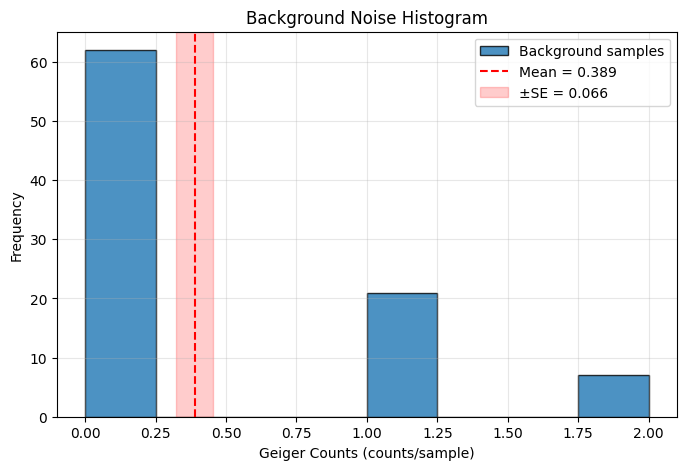

In [381]:
noices = []
for name in noise_names:
    data = df(f"noise/{name}.csv")[field_names[1]].to_numpy()
    avg_data = np.mean(data)
    noices.append(avg_data)

noise = np.average(noices)

noise_samples = np.concatenate(
    [df(f"noise/{n}.csv")[field_names[1]].to_numpy() for n in noise_names]
)

# Standard error of the mean (SEM)
noise_mean = noise_samples.mean()
noise_std = np.std(noise_samples, ddof=1)
noise_se = noise_std / np.sqrt(len(noise_samples))

plt.figure(figsize=(8, 5))
plt.hist(noise_samples, bins="auto", edgecolor="black", alpha=0.8, label="Background samples")
plt.axvline(noise_mean, color="red", linestyle="--", label=f"Mean = {noise_mean:.3f}")
plt.axvspan(noise_mean - noise_se, noise_mean + noise_se, color="red", alpha=0.2, label=f"±SE = {noise_se:.3f}")

plt.title("Background Noise Histogram")
plt.xlabel("Geiger Counts (counts/sample)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.legend()



plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


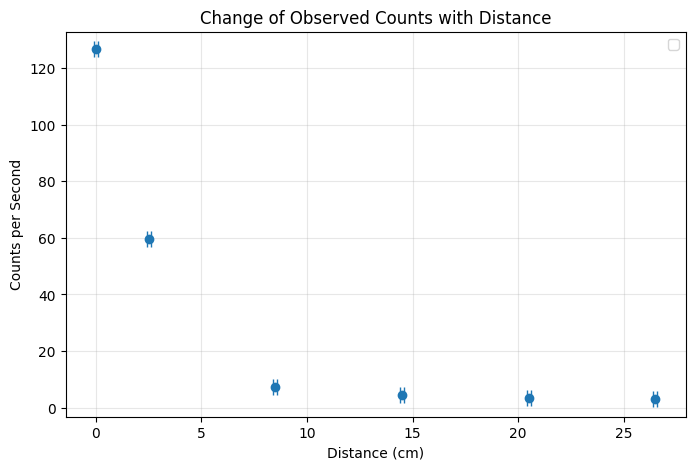

In [382]:
# Extract distances and average counts per second from the runs dict
distances = []
avg_counts = []

for key, dist in runs.items():
    data = df(f"length_data/{key}.csv")[" Geiger Counts (counts/sample)"].to_numpy()
    avg_val = np.mean(data)
    if dist == 2.5:
        avg_val *= 5 
    distances.append(dist)
    avg_counts.append(avg_val)

distances = np.array(distances)
avg_counts = np.array(avg_counts)

# Sort by distance
sort_idx = np.argsort(distances)
distances = distances[sort_idx]
avg_counts = avg_counts[sort_idx]

plt.figure(figsize=(8, 5))
plt.errorbar(distances, avg_counts, xerr=0.1, fmt='o', markersize=6, capsize=6,)
plt.xlabel("Distance (cm)")
plt.ylabel("Counts per Second")
plt.title("Change of Observed Counts with Distance")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [383]:
#equations

#Poisson distribution
def poisson(x, mew):
    eq = ((mew**x)* math.exp(-mew))/(math.gamma(x + 1))
    return eq

##gaussian distribution
def gausian(x, mew, sigma):
    eq = math.exp(-((x- mew)**2)/(2*(sigma**2)))/(math.sqrt(2*math.pi*(sigma**2)))
    return eq

In [384]:
'''from scipy.stats import iqr

for filename in histogram_data_names:
    data = df(f"sampling_tests/{filename}")[field_names[1]].to_numpy()
    plt.figure()
    
    mew = np.mean(data)
    sigma = np.std(data)
    
    # Freedman-Diaconis rule for bin width
    data_iqr = iqr(data)
    bin_width = 2 * data_iqr / (len(data) ** (1/3))
    if bin_width == 0:
        bin_width = 1  # fallback for zero IQR
    x_min = int(np.min(data))
    x_max = int(np.max(data))
    num_bins = max(1, int(np.ceil((x_max - x_min) / bin_width)))
    
    min_bins_required = 4
    if num_bins < min_bins_required:
        num_bins = min_bins_required
    
    obs_hist, bin_edges, _ = plt.hist(data, bins=num_bins, alpha=1, density=True, label="Histogram")
    
    x = np.arange(x_min, x_max + 1)

    x_smooth = np.linspace(x_min, x_max, 200)
    gauss_y_smooth = np.array([gausian(val, mew, sigma) for val in x_smooth])
    plt.plot(x_smooth, gauss_y_smooth, 'r-', label="Gaussian (normalized)")
    
    pois_y = np.array([poisson(val, mew) for val in x])
    plt.plot(x, pois_y, 'g--', label="Poisson (normalized)")
    
    obs_counts = np.array([np.sum(data == val) for val in x])
    
    exp_gauss = np.array([gausian(val, mew, sigma) for val in x])
    exp_gauss = exp_gauss / exp_gauss.sum() * obs_counts.sum()
    
    exp_pois = np.array([poisson(val, mew) for val in x])
    exp_pois = exp_pois / exp_pois.sum() * obs_counts.sum()
    
    def merge_small_bins(obs, exp, min_exp=5):
        obs_m, exp_m = [], []
        o_acc, e_acc = 0, 0
        for o, e in zip(obs, exp):
            o_acc += o
            e_acc += e
            if e_acc >= min_exp:
                obs_m.append(o_acc)
                exp_m.append(e_acc)
                o_acc, e_acc = 0, 0
        if e_acc > 0:
            if len(obs_m) > 0:
                obs_m[-1] += o_acc
                exp_m[-1] += e_acc
            else:
                obs_m.append(o_acc)
                exp_m.append(e_acc)
        return np.array(obs_m), np.array(exp_m)
    
    obs_g, exp_g = merge_small_bins(obs_counts, exp_gauss)
    obs_p, exp_p = merge_small_bins(obs_counts, exp_pois)
    
    k_g = len(obs_g)
    k_p = len(obs_p)
    dof_g = k_g - 1 - 2
    dof_p = k_p - 1 - 1
    
    if dof_g <= 0 or dof_p <= 0:
        num_bins = max(num_bins, x_max - x_min + 1)
        plt.clf()
        obs_hist, bin_edges, _ = plt.hist(data, bins=num_bins, alpha=1, density=True, label="Histogram")
        plt.plot(x_smooth, gauss_y_smooth, 'r-', label="Gaussian (normalized)")
        plt.plot(x, pois_y, 'g--', label="Poisson (normalized)")
        for min_exp_threshold in [5, 3, 1]:
            obs_g, exp_g = merge_small_bins(obs_counts, exp_gauss, min_exp=min_exp_threshold)
            obs_p, exp_p = merge_small_bins(obs_counts, exp_pois, min_exp=min_exp_threshold)
            k_g = len(obs_g)
            k_p = len(obs_p)
            dof_g = k_g - 1 - 2
            dof_p = k_p - 1 - 1
            if dof_g > 0 and dof_p > 0:
                break
    
    chi_gaussian = chisquare(obs_g, f_exp=exp_g, ddof=2)
    chi_poisson = chisquare(obs_p, f_exp=exp_p, ddof=1)
    
    red_chi_g = chi_gaussian.statistic / dof_g if dof_g > 0 else float('inf')
    red_chi_p = chi_poisson.statistic / dof_p if dof_p > 0 else float('inf')
    
    # Update legend labels with χ²/dof values
    ax = plt.gca()
    lines = ax.get_lines()
    for line in lines:
        lbl = line.get_label()
        if 'Gaussian' in lbl:
            line.set_label(f"Gaussian (χ²/dof={red_chi_g:.2f})")
        elif 'Poisson' in lbl:
            line.set_label(f"Poisson (χ²/dof={red_chi_p:.2f})")
    
    plt.title(f"Histogram with Gaussian & Poisson for {filename}")
    plt.xlabel("Geiger Counts (counts/sample)")
    plt.ylabel("Density")
    plt.grid()
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
'''

'from scipy.stats import iqr\n\nfor filename in histogram_data_names:\n    data = df(f"sampling_tests/{filename}")[field_names[1]].to_numpy()\n    plt.figure()\n\n    mew = np.mean(data)\n    sigma = np.std(data)\n\n    # Freedman-Diaconis rule for bin width\n    data_iqr = iqr(data)\n    bin_width = 2 * data_iqr / (len(data) ** (1/3))\n    if bin_width == 0:\n        bin_width = 1  # fallback for zero IQR\n    x_min = int(np.min(data))\n    x_max = int(np.max(data))\n    num_bins = max(1, int(np.ceil((x_max - x_min) / bin_width)))\n\n    min_bins_required = 4\n    if num_bins < min_bins_required:\n        num_bins = min_bins_required\n\n    obs_hist, bin_edges, _ = plt.hist(data, bins=num_bins, alpha=1, density=True, label="Histogram")\n\n    x = np.arange(x_min, x_max + 1)\n\n    x_smooth = np.linspace(x_min, x_max, 200)\n    gauss_y_smooth = np.array([gausian(val, mew, sigma) for val in x_smooth])\n    plt.plot(x_smooth, gauss_y_smooth, \'r-\', label="Gaussian (normalized)")\n\n    

1Hz: 3.572706354023478%
1Hz - Mean: 191.4833 ± 2.6705 (incl. noise SE=0.0665)
1Hz - Corrected mean (noise subtracted): 191.0944 ± 2.6705
1Hz - Gaussian fit R^2: 0.342
1Hz - Poisson fit R^2: 0.337
1Hz - Chi-square Gaussian: stat=15.264, dof=8, p=0.054, χ²/dof=1.908
1Hz - Chi-square Poisson: stat=8.737, dof=8, p=0.365, χ²/dof=1.092
1Hz - Merge small bins: ON
1Hz - Number of histogram bins (Freedman-Diaconis): 12
1Hz - Better fit: Poisson


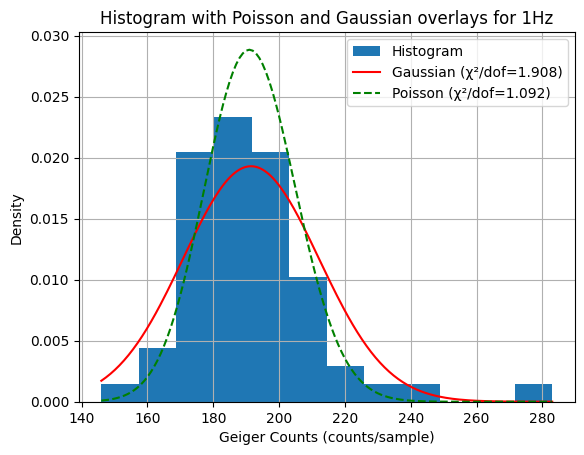

5Hz: -1.4343233164861617%
5Hz - Mean: 14.9670 ± 0.2202 (incl. noise SE=0.0665)
5Hz - Corrected mean (noise subtracted): 14.5781 ± 0.2202
5Hz - Gaussian fit R^2: 0.894
5Hz - Poisson fit R^2: 0.914
5Hz - Chi-square Gaussian: stat=11.941, dof=13, p=0.532, χ²/dof=0.919
5Hz - Chi-square Poisson: stat=9.559, dof=14, p=0.794, χ²/dof=0.683
5Hz - Merge small bins: ON
5Hz - Number of histogram bins (Freedman-Diaconis): 11
5Hz - Better fit: Poisson


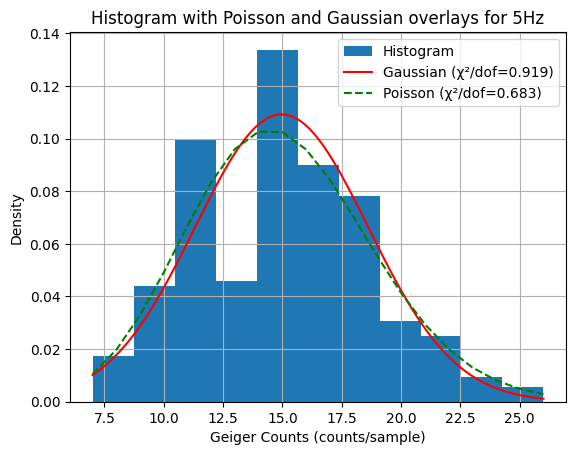

10Hz: -2.0288046019973307%
10Hz - Mean: 7.3185 ± 0.1233 (incl. noise SE=0.0665)
10Hz - Corrected mean (noise subtracted): 6.9296 ± 0.1233
10Hz - Gaussian fit R^2: 0.977
10Hz - Poisson fit R^2: 0.962
10Hz - Chi-square Gaussian: stat=16.774, dof=9, p=0.052, χ²/dof=1.864
10Hz - Chi-square Poisson: stat=12.022, dof=11, p=0.362, χ²/dof=1.093
10Hz - Merge small bins: ON
10Hz - Number of histogram bins (Freedman-Diaconis): 22
10Hz - Better fit: Poisson


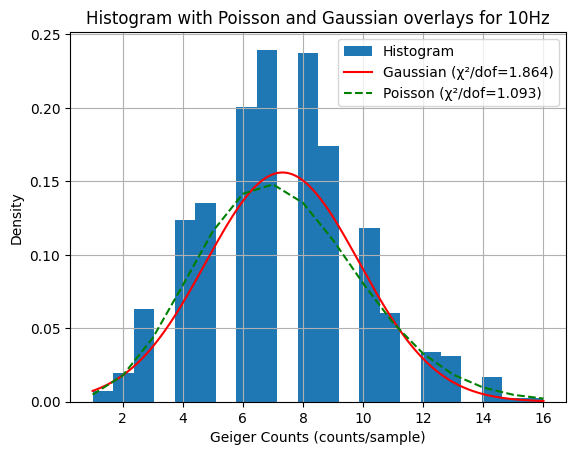

25Hz: -2.4623994414923045%
25Hz - Mean: 2.9081 ± 0.0786 (incl. noise SE=0.0665)
25Hz - Corrected mean (noise subtracted): 2.5192 ± 0.0786
25Hz - Gaussian fit R^2: 0.969
25Hz - Poisson fit R^2: 0.991
25Hz - Chi-square Gaussian: stat=38.969, dof=5, p=0.000, χ²/dof=7.794
25Hz - Chi-square Poisson: stat=8.831, dof=7, p=0.265, χ²/dof=1.262
25Hz - Merge small bins: ON
25Hz - Number of histogram bins (Freedman-Diaconis): 29
25Hz - Better fit: Poisson


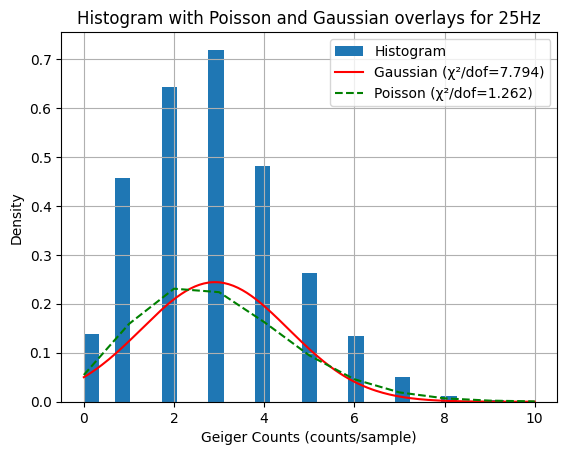

40Hz: -1.1780073941289726%
40Hz - Mean: 2.1549 ± 0.0726 (incl. noise SE=0.0665)
40Hz - Corrected mean (noise subtracted): 1.7661 ± 0.0726
40Hz - Gaussian fit R^2: 0.959
40Hz - Poisson fit R^2: 0.997
40Hz - Chi-square Gaussian: stat=99.830, dof=4, p=0.000, χ²/dof=24.958
40Hz - Chi-square Poisson: stat=5.097, dof=6, p=0.531, χ²/dof=0.850
40Hz - Merge small bins: ON
40Hz - Number of histogram bins (Freedman-Diaconis): 27
40Hz - Better fit: Poisson


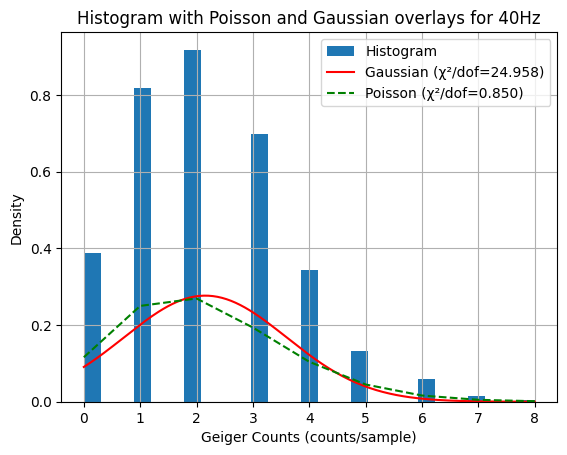

50Hz: -2.28852238763849%
50Hz - Mean: 1.7579 ± 0.0705 (incl. noise SE=0.0665)
50Hz - Corrected mean (noise subtracted): 1.3690 ± 0.0705
50Hz - Gaussian fit R^2: 0.943
50Hz - Poisson fit R^2: 0.996
50Hz - Chi-square Gaussian: stat=131.513, dof=3, p=0.000, χ²/dof=43.838
50Hz - Chi-square Poisson: stat=6.949, dof=6, p=0.326, χ²/dof=1.158
50Hz - Merge small bins: ON
50Hz - Number of histogram bins (Freedman-Diaconis): 26
50Hz - Better fit: Poisson


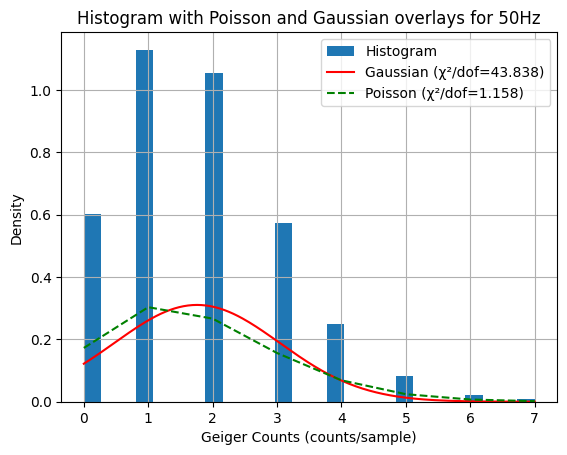

In [385]:
from scipy.special import gammaln

#some_more = ["Data_5Hz_1min_2.5cm.csv","test_5Hz_1min.csv"]
some_more = ["test_1Hz_1min_closer.csv","test_5Hz_1min.csv","test_10Hz_1min.csv", "test_25Hz_1min.csv", "test_40Hz_1min.csv", "test_50Hz_1min.csv"] 
labels = ["1Hz", "5Hz", "10Hz", "25Hz", "40Hz", "50Hz"]
merge_small = True  # Set to False to disable merging of small bins

for filename, label in zip(some_more, labels):
    data = df(f"data/{filename}")[field_names[1]].to_numpy()
    quarter_len = len(data)
    data = data[:quarter_len]
    
    # Subtract noise mean and propagate noise standard error
    data_corrected = data - noise_mean
    plt.figure()
    
    mew = np.mean(data)
    sigma = np.std(data)
    
    # Propagate noise_se into the uncertainty of the mean
    mew_corrected = mew - noise_mean
    sigma_mew = np.sqrt((sigma / np.sqrt(len(data)))**2 + noise_se**2)
    
    difference = -np.sqrt(mew) + sigma
    difference_percent = (difference / mew) * 100
    print(f"{label}: {difference_percent}%")
    print(f"{label} - Mean: {mew:.4f} ± {sigma_mew:.4f} (incl. noise SE={noise_se:.4f})")
    print(f"{label} - Corrected mean (noise subtracted): {mew_corrected:.4f} ± {sigma_mew:.4f}")
    
    # Use integer bins for discrete data
    x_min = int(np.min(data))
    x_max = int(np.max(data))
    bins = np.arange(x_min, x_max + 2) - 0.5  # center bins on integers
    
    # Freedman-Diaconis rule for number of bins
    data_iqr = np.subtract(*np.percentile(data, [75, 25]))
    n = len(data)
    if data_iqr > 0:
        bin_width_fd = 2 * data_iqr * n ** (-1/3)
        num_bins = max(4, int(np.ceil((data.max() - data.min()) / bin_width_fd)))
    else:
        num_bins = 4
    
    plt.hist(data, bins=num_bins, alpha=1, density=True, label="Histogram")
    
    x = np.arange(x_min, x_max + 1)

    # Gaussian plot
    x_smooth = np.linspace(x_min, x_max, 200)
    gauss_y_smooth = np.array([gausian(val, mew, sigma) for val in x_smooth])
    plt.plot(x_smooth, gauss_y_smooth, 'r-', label="Gaussian (normalized)")
    
    # Poisson plot - use log-space to avoid overflow with large values
    def poisson_safe(x, mu):
        return np.exp(x * np.log(mu) - mu - gammaln(x + 1))
    
    pois_y = np.array([poisson_safe(val, mew) for val in x])
    plt.plot(x, pois_y, 'g--', label="Poisson (normalized)")
    
    # Observed counts per integer value
    obs_counts = np.array([np.sum(data == val) for val in x])
    
    # Expected counts
    exp_gauss = np.array([gausian(val, mew, sigma) for val in x])
    exp_gauss = exp_gauss / exp_gauss.sum() * obs_counts.sum()
    
    exp_pois = np.array([poisson_safe(val, mew) for val in x])
    exp_pois = exp_pois / exp_pois.sum() * obs_counts.sum()
    
    # Merge bins with expected < 5 (chi-square requirement)
    def merge_small_bins(obs, exp, min_exp=5):
        obs_m, exp_m = [], []
        o_acc, e_acc = 0, 0
        for o, e in zip(obs, exp):
            o_acc += o
            e_acc += e
            if e_acc >= min_exp:
                obs_m.append(o_acc)
                exp_m.append(e_acc)
                o_acc, e_acc = 0, 0
        if e_acc > 0:
            obs_m[-1] += o_acc
            exp_m[-1] += e_acc
        return np.array(obs_m), np.array(exp_m)
    
    if merge_small:
        obs_g, exp_g = merge_small_bins(obs_counts, exp_gauss)
        obs_p, exp_p = merge_small_bins(obs_counts, exp_pois)
    else:
        obs_g, exp_g = obs_counts, exp_gauss
        obs_p, exp_p = obs_counts, exp_pois
    
    # R^2 values
    hist_vals = obs_counts / (obs_counts.sum())
    gauss_fit_vals = exp_gauss / exp_gauss.sum()
    pois_fit_vals = exp_pois / exp_pois.sum()
    
    ss_tot = np.sum((hist_vals - np.mean(hist_vals)) ** 2)
    r2 = 1 - np.sum((hist_vals - gauss_fit_vals) ** 2) / ss_tot
    r2_pois = 1 - np.sum((hist_vals - pois_fit_vals) ** 2) / ss_tot
    print(f"{label} - Gaussian fit R^2: {r2:.3f}")
    print(f"{label} - Poisson fit R^2: {r2_pois:.3f}")
    
    # ddof: 1 for Poisson (estimated mu), 2 for Gaussian (estimated mu, sigma)
    chi_gaussian = chisquare(obs_g, f_exp=exp_g, ddof=2)
    chi_poisson = chisquare(obs_p, f_exp=exp_p, ddof=1)
    
    dof_g = len(obs_g) - 1 - 2  # number of bins - 1 - estimated params
    dof_p = len(obs_p) - 1 - 1
    red_chi_g = chi_gaussian.statistic / dof_g if dof_g > 0 else float('inf')
    red_chi_p = chi_poisson.statistic / dof_p if dof_p > 0 else float('inf')
    
    print(f"{label} - Chi-square Gaussian: stat={chi_gaussian.statistic:.3f}, dof={dof_g}, p={chi_gaussian.pvalue:.3f}, χ²/dof={red_chi_g:.3f}")
    print(f"{label} - Chi-square Poisson: stat={chi_poisson.statistic:.3f}, dof={dof_p}, p={chi_poisson.pvalue:.3f}, χ²/dof={red_chi_p:.3f}")
    print(f"{label} - Merge small bins: {'ON' if merge_small else 'OFF'}")
    print(f"{label} - Number of histogram bins (Freedman-Diaconis): {num_bins}")
    print(f"{label} - Better fit:", "Poisson" if chi_poisson.statistic < chi_gaussian.statistic else "Gaussian")
    
    plt.title(f"Histogram with Poisson and Gaussian overlays for {label}")
    plt.xlabel("Geiger Counts (counts/sample)")
    plt.ylabel("Density")
    plt.grid()
    
    # Update legend labels with chi²/dof values
    ax = plt.gca()
    handles, labels_list = ax.get_legend_handles_labels()
    new_labels = []
    for lbl in labels_list:
        if lbl == "Gaussian (normalized)":
            new_labels.append(f"Gaussian (χ²/dof={red_chi_g:.3f})")
        elif lbl == "Poisson (normalized)":
            new_labels.append(f"Poisson (χ²/dof={red_chi_p:.3f})")
        else:
            new_labels.append(lbl)
    plt.legend(handles, new_labels)
    plt.show()

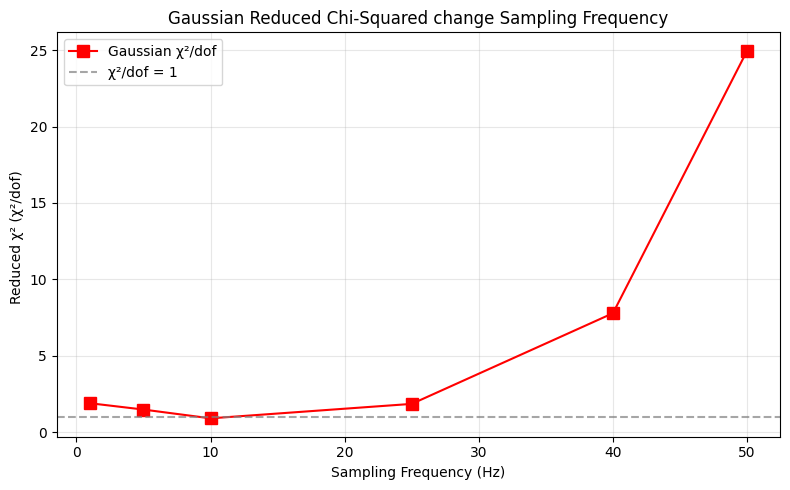

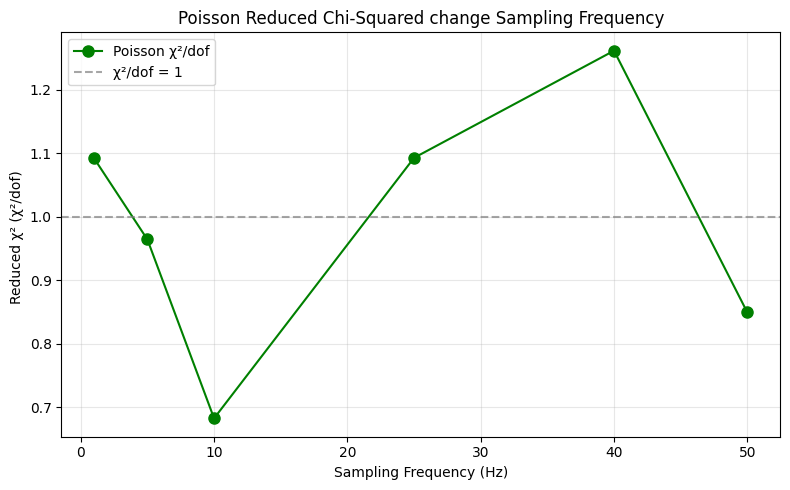

In [391]:
# Extract the sampling frequencies and chi²/dof values from cell 6 results
hz_values = [1, 5, 10, 25, 40, 50]

red_chi_g_list = []
red_chi_p_list = []

for filename, label in zip(some_more, labels):
    data_tmp = df(f"data/{filename}")[field_names[1]].to_numpy()
    
    mew_tmp = np.mean(data_tmp)
    sigma_tmp = np.std(data_tmp)
    
    x_min_tmp = int(np.min(data_tmp))
    x_max_tmp = int(np.max(data_tmp))
    
    x_tmp = np.arange(x_min_tmp, x_max_tmp + 1)
    
    obs_counts_tmp = np.array([np.sum(data_tmp == val) for val in x_tmp])
    
    exp_gauss_tmp = np.array([gausian(val, mew_tmp, sigma_tmp) for val in x_tmp])
    exp_gauss_tmp = exp_gauss_tmp / exp_gauss_tmp.sum() * obs_counts_tmp.sum()
    
    def poisson_safe_tmp(x_val, mu):
        return np.exp(x_val * np.log(mu) - mu - gammaln(x_val + 1))
    
    exp_pois_tmp = np.array([poisson_safe_tmp(val, mew_tmp) for val in x_tmp])
    exp_pois_tmp = exp_pois_tmp / exp_pois_tmp.sum() * obs_counts_tmp.sum()
    
    def merge_small_bins_tmp(obs, exp, min_exp=5):
        obs_m, exp_m = [], []
        o_acc, e_acc = 0, 0
        for o, e in zip(obs, exp):
            o_acc += o
            e_acc += e
            if e_acc >= min_exp:
                obs_m.append(o_acc)
                exp_m.append(e_acc)
                o_acc, e_acc = 0, 0
        if e_acc > 0:
            obs_m[-1] += o_acc
            exp_m[-1] += e_acc
        return np.array(obs_m), np.array(exp_m)
    
    obs_g_tmp, exp_g_tmp = merge_small_bins_tmp(obs_counts_tmp, exp_gauss_tmp)
    obs_p_tmp, exp_p_tmp = merge_small_bins_tmp(obs_counts_tmp, exp_pois_tmp)
    
    chi_g_tmp = chisquare(obs_g_tmp, f_exp=exp_g_tmp, ddof=2)
    chi_p_tmp = chisquare(obs_p_tmp, f_exp=exp_p_tmp, ddof=1)
    
    dof_g_tmp = len(obs_g_tmp) - 1 - 2
    dof_p_tmp = len(obs_p_tmp) - 1 - 1
    
    red_chi_g_list.append(chi_g_tmp.statistic / dof_g_tmp if dof_g_tmp > 0 else float('inf'))
    red_chi_p_list.append(chi_p_tmp.statistic / dof_p_tmp if dof_p_tmp > 0 else float('inf'))

# Plot 1: Gaussian chi²/dof
fig1, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(hz_values, red_chi_g_list, 'rs-', markersize=8, label="Gaussian χ²/dof")
ax1.axhline(y=1, color='gray', linestyle='--', alpha=0.7, label="χ²/dof = 1")
ax1.set_xlabel("Sampling Frequency (Hz)")
ax1.set_ylabel("Reduced χ² (χ²/dof) ")
ax1.set_title("Gaussian Reduced Chi-Squared change Sampling Frequency")
ax1.grid(alpha=0.3)
ax1.legend()
plt.tight_layout()
plt.show()

# Plot 2: Poisson chi²/dof
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.plot(hz_values, red_chi_p_list, 'go-', markersize=8, label="Poisson χ²/dof")
ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.7, label="χ²/dof = 1")
ax2.set_xlabel("Sampling Frequency (Hz)")
ax2.set_ylabel("Reduced χ² (χ²/dof) ")
ax2.set_title("Poisson Reduced Chi-Squared change Sampling Frequency")
ax2.grid(alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.show()

In [387]:
'''from scipy.stats import chi2 as chi2_dist

#some_more = ["Data_5Hz_1min_2.5cm.csv"]
some_more = [
    "5Hz_Run1.csv",
    "5Hz_Run2.csv",
    "5Hz_run3.csv",
    "5Hz_Run4.csv",
    "5Hz_Run5.csv",
    "5Hz_Run6.csv",
    "5Hz_Run7.csv",
    "5Hz_Run9.csv",
    "5Hz_Run10.csv",
]

num_bins = 20 # Change this value to adjust the number of bins
merge_small = False  # Set to False to disable merging of small bins

for filename in some_more:
    data = df(f"data_5hz/{filename}")[field_names[1]].to_numpy()
    quarter_len = len(data)
    data = data[:quarter_len]
    plt.figure()
    
    mew = np.mean(data)
    sigma = np.std(data)
    
    difference = -np.sqrt(mew) + sigma
    difference_percent = (difference / mew) * 100
    print(f"{difference_percent}%")
    
    # Use integer bins for discrete data
    x_min = int(np.min(data))
    x_max = int(np.max(data))
    bins = np.arange(x_min, x_max + 2) - 0.5  # center bins on integers
    
    plt.hist(data, bins=num_bins, alpha=1, density=True, label="Histogram")
    
    x = np.arange(x_min, x_max + 1)

    # Gaussian plot
    x_smooth = np.linspace(x_min, x_max, 200)
    gauss_y_smooth = np.array([gausian(val, mew, sigma) for val in x_smooth])
    plt.plot(x_smooth, gauss_y_smooth, 'r-', label="Gaussian (normalized)")
    
    # Poisson plot - use log-space to avoid overflow with large values
    def poisson_safe(x, mu):
        return np.exp(x * np.log(mu) - mu - gammaln(x + 1))
    
    pois_y = np.array([poisson_safe(val, mew) for val in x])
    plt.plot(x, pois_y, 'g--', label="Poisson (normalized)")
    
    # Observed counts per integer value
    obs_counts = np.array([np.sum(data == val) for val in x])
    
    # Expected counts
    exp_gauss = np.array([gausian(val, mew, sigma) for val in x])
    exp_gauss = exp_gauss / exp_gauss.sum() * obs_counts.sum()
    
    exp_pois = np.array([poisson_safe(val, mew) for val in x])
    exp_pois = exp_pois / exp_pois.sum() * obs_counts.sum()
    
    # Merge bins with expected < 5 (chi-square requirement)
    def merge_small_bins(obs, exp, min_exp=5):
        obs_m, exp_m = list(obs), list(exp)
        # Merge from the left
        while len(exp_m) > 1 and exp_m[0] < min_exp:
            obs_m[1] += obs_m[0]
            exp_m[1] += exp_m[0]
            obs_m.pop(0)
            exp_m.pop(0)
        # Merge from the right
        while len(exp_m) > 1 and exp_m[-1] < min_exp:
            obs_m[-2] += obs_m[-1]
            exp_m[-2] += exp_m[-1]
            obs_m.pop()
            exp_m.pop()
        # Merge any remaining interior bins with small expected counts
        i = 0
        while i < len(exp_m):
            if exp_m[i] < min_exp and len(exp_m) > 1:
                if i < len(exp_m) - 1:
                    obs_m[i + 1] += obs_m[i]
                    exp_m[i + 1] += exp_m[i]
                else:
                    obs_m[i - 1] += obs_m[i]
                    exp_m[i - 1] += exp_m[i]
                obs_m.pop(i)
                exp_m.pop(i)
            else:
                i += 1
        return np.array(obs_m), np.array(exp_m)
    
    # Always merge for chi-squared to ensure validity
    obs_g, exp_g = merge_small_bins(obs_counts, exp_gauss)
    obs_p, exp_p = merge_small_bins(obs_counts, exp_pois)
    
    k_g = len(obs_g)
    k_p = len(obs_p)
    ddof_g = 2  # estimated mu and sigma
    ddof_p = 1  # estimated mu
    dof_g = k_g - 1 - ddof_g
    dof_p = k_p - 1 - ddof_p
    
    # R^2 values
    hist_vals = obs_counts / (obs_counts.sum())
    gauss_fit_vals = exp_gauss / exp_gauss.sum()
    pois_fit_vals = exp_pois / exp_pois.sum()
    
    ss_tot = np.sum((hist_vals - np.mean(hist_vals)) ** 2)
    r2 = 1 - np.sum((hist_vals - gauss_fit_vals) ** 2) / ss_tot
    r2_pois = 1 - np.sum((hist_vals - pois_fit_vals) ** 2) / ss_tot
    print(f"Gaussian fit R^2: {r2:.3f}")
    print(f"Poisson fit R^2: {r2_pois:.3f}")
    
    # Ensure degrees of freedom are valid
    if dof_g > 0:
        chi_stat_g = np.sum((obs_g - exp_g) ** 2 / exp_g)
        chi_p_g = 1 - chi2_dist.cdf(chi_stat_g, dof_g)
        print(f"Chi-square Gaussian: stat={chi_stat_g:.3f}, dof={dof_g}, p={chi_p_g:.3f}")
    else:
        print(f"Chi-square Gaussian: not enough bins (k={k_g}, dof={dof_g})")
    
    if dof_p > 0:
        chi_stat_p = np.sum((obs_p - exp_p) ** 2 / exp_p)
        chi_p_p = 1 - chi2_dist.cdf(chi_stat_p, dof_p)
        print(f"Chi-square Poisson: stat={chi_stat_p:.3f}, dof={dof_p}, p={chi_p_p:.3f}")
    else:
        print(f"Chi-square Poisson: not enough bins (k={k_p}, dof={dof_p})")
    
    print(f"Bins after merging (Gaussian): {k_g}, (Poisson): {k_p}")
    if dof_g > 0 and dof_p > 0:
        # Compare reduced chi-squared for fair comparison
        red_chi_g = chi_stat_g / dof_g
        red_chi_p = chi_stat_p / dof_p
        print(f"Reduced chi-sq Gaussian: {red_chi_g:.3f}, Poisson: {red_chi_p:.3f}")
        print("Better fit:", "Poisson" if red_chi_p < red_chi_g else "Gaussian")
    
    plt.title(f"Histogram with Gaussian & Poisson for {filename}")
    plt.xlabel("Geiger Counts (counts/sample)")
    plt.ylabel("Density")
    plt.grid()
    plt.legend()
    plt.show()'''

'from scipy.stats import chi2 as chi2_dist\n\n#some_more = ["Data_5Hz_1min_2.5cm.csv"]\nsome_more = [\n    "5Hz_Run1.csv",\n    "5Hz_Run2.csv",\n    "5Hz_run3.csv",\n    "5Hz_Run4.csv",\n    "5Hz_Run5.csv",\n    "5Hz_Run6.csv",\n    "5Hz_Run7.csv",\n    "5Hz_Run9.csv",\n    "5Hz_Run10.csv",\n]\n\nnum_bins = 20 # Change this value to adjust the number of bins\nmerge_small = False  # Set to False to disable merging of small bins\n\nfor filename in some_more:\n    data = df(f"data_5hz/{filename}")[field_names[1]].to_numpy()\n    quarter_len = len(data)\n    data = data[:quarter_len]\n    plt.figure()\n\n    mew = np.mean(data)\n    sigma = np.std(data)\n\n    difference = -np.sqrt(mew) + sigma\n    difference_percent = (difference / mew) * 100\n    print(f"{difference_percent}%")\n\n    # Use integer bins for discrete data\n    x_min = int(np.min(data))\n    x_max = int(np.max(data))\n    bins = np.arange(x_min, x_max + 2) - 0.5  # center bins on integers\n\n    plt.hist(data, bins=num_bi

3.1119343287322874%
Fitted Gaussian: mu=21.9150, sigma=5.4783
Sample Gaussian: mu=21.9165, sigma=5.3635
Fitted Poisson: mu=21.6788
Sample Poisson: mu=21.9165
Gaussian fit R^2: 0.975
Poisson fit R^2: 0.910
Chi-square Gaussian: stat=27.835, p=0.006 (reduced=2.320, dof=12)
Chi-square Poisson: stat=229.716, p=0.000 (reduced=17.670, dof=13)
Merge small bins: OFF
Better fit: Gaussian


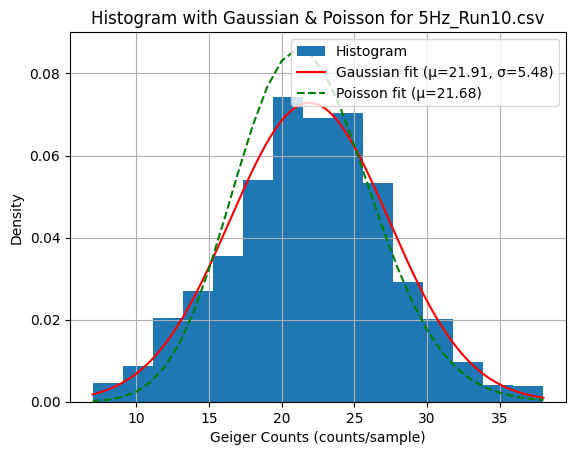

In [ ]:
from scipy.special import gammaln
from scipy.optimize import minimize_scalar, minimize


#some_more = ["Data_5Hz_1min_2.5cm.csv"]
some_more = [
    "5Hz_Run1.csv",
    "5Hz_Run2.csv",
    "5Hz_run3.csv",
    "5Hz_Run4.csv",
    "5Hz_Run5.csv",
    "5Hz_Run6.csv",
    "5Hz_Run7.csv",
    "5Hz_Run9.csv",
    "5Hz_Run10.csv",
]

# Combine all data into one array
all_data = []
for filename in some_more:
    data = df(f"data_5hz/{filename}")[field_names[1]].to_numpy()
    quarter_len = len(data)
    data = data[:quarter_len]
    all_data.append(data)

data = np.concatenate(all_data)


#some_more = ["Data_5Hz_1min_2.5cm.csv"]
some_more = ["test_1Hz_1min_closer.csv","Data_5Hz_1min_2.5cm.csv","test_5Hz_1min.csv","test_10Hz_1min.csv", "test_25Hz_1min.csv", "test_40Hz_1min.csv", "test_50Hz_1min.csv"] 

num_bins = 15  # Change this value to adjust the number of bins
merge_small = False  # Set to False to disable merging of small bins

for i in range(1):
    #data = df(f"data/{filename}")[field_names[1]].to_numpy()
    
    quarter_len = len(data)
    data = data[:quarter_len]
    plt.figure()
    
    mu = np.mean(data)
    sig = np.std(data)
    
    difference = -np.sqrt(mu) + sig
    difference_percent = (difference / mu) * 100
    print(f"{difference_percent}%")
    
    # Use integer bins for discrete data
    x_min = int(np.min(data))
    x_max = int(np.max(data))
    bins = np.arange(x_min, x_max + 2) - 0.5  # center bins on integers
    
    # Plot histogram and capture bin edges
    obs_counts_hist, bin_edges, _ = plt.hist(data, bins=num_bins, alpha=1, density=True, label="Histogram")
    
    x = np.arange(x_min, x_max + 1)

    # --- Get observed counts (not density) using the same bin edges ---
    obs_counts_hist_raw, _ = np.histogram(data, bins=bin_edges)
    N_total = obs_counts_hist_raw.sum()

    # --- Fit Gaussian parameters to histogram via chi-square minimization ---
    def chi2_gauss(params):
        mu_p, sig_p = params
        if sig_p <= 0:
            return 1e20
        exp_hist = np.zeros(len(bin_edges) - 1)
        for b in range(len(bin_edges) - 1):
            lo = int(np.ceil(bin_edges[b]))
            hi = int(np.floor(bin_edges[b + 1]))
            for val in range(lo, hi + 1):
                exp_hist[b] += gausian(val, mu_p, sig_p)
        exp_hist = exp_hist / exp_hist.sum() * N_total
        mask = exp_hist > 0
        return np.sum((obs_counts_hist_raw[mask] - exp_hist[mask]) ** 2 / exp_hist[mask])

    res_gauss = minimize(chi2_gauss, x0=[mu, sig], method='Nelder-Mead')
    mu_fit, sig_fit = res_gauss.x
    print(f"Fitted Gaussian: μ={mu_fit:.4f}, σ={sig_fit:.4f}")
    print(f"Sample Gaussian: μ={mu:.4f}, σ={sig:.4f}")

    # --- Fit Poisson parameter to histogram via chi-square minimization ---
    def poisson_safe(x, mu_val):
        return np.exp(x * np.log(mu_val) - mu_val - gammaln(x + 1))

    def chi2_pois(mu_val):
        if mu_val <= 0:
            return 1e20
        exp_hist = np.zeros(len(bin_edges) - 1)
        for b in range(len(bin_edges) - 1):
            lo = int(np.ceil(bin_edges[b]))
            hi = int(np.floor(bin_edges[b + 1]))
            for val in range(lo, hi + 1):
                exp_hist[b] += poisson_safe(val, mu_val)
        exp_hist = exp_hist / exp_hist.sum() * N_total
        mask = exp_hist > 0
        return np.sum((obs_counts_hist_raw[mask] - exp_hist[mask]) ** 2 / exp_hist[mask])

    res_pois = minimize_scalar(chi2_pois, bounds=(1, x_max), method='bounded')
    mu_pois_fit = res_pois.x
    print(f"Fitted Poisson: μ={mu_pois_fit:.4f}")
    print(f"Sample Poisson: μ={mu:.4f}")

    # Gaussian plot using FITTED parameters
    x_smooth = np.linspace(x_min, x_max, 200)
    gauss_y_smooth = np.array([gausian(val, mu_fit, sig_fit) for val in x_smooth])
    plt.plot(x_smooth, gauss_y_smooth, 'r-', label=f"Gaussian fit (μ={mu_fit:.2f}, σ={sig_fit:.2f})")
    
    # Poisson plot using FITTED parameter
    pois_y = np.array([poisson_safe(val, mu_pois_fit) for val in x])
    plt.plot(x, pois_y, 'g--', label=f"Poisson fit (μ={mu_pois_fit:.2f})")
    
    # Expected counts for each histogram bin using FITTED parameters
    exp_gauss_hist = np.zeros(len(bin_edges) - 1)
    exp_pois_hist = np.zeros(len(bin_edges) - 1)
    for b in range(len(bin_edges) - 1):
        lo = int(np.ceil(bin_edges[b]))
        hi = int(np.floor(bin_edges[b + 1]))
        for val in range(lo, hi + 1):
            exp_gauss_hist[b] += gausian(val, mu_fit, sig_fit)
            exp_pois_hist[b] += poisson_safe(val, mu_pois_fit)
    
    # Normalize expected counts to match total observed
    exp_gauss_hist = exp_gauss_hist / exp_gauss_hist.sum() * N_total
    exp_pois_hist = exp_pois_hist / exp_pois_hist.sum() * N_total
    
    # Merge bins with expected < 5 (chi-square requirement)
    def merge_small_bins(obs, exp, min_exp=5):
        obs_m, exp_m = [], []
        o_acc, e_acc = 0, 0
        for o, e in zip(obs, exp):
            o_acc += o
            e_acc += e
            if e_acc >= min_exp:
                obs_m.append(o_acc)
                exp_m.append(e_acc)
                o_acc, e_acc = 0, 0
        if e_acc > 0:
            if len(obs_m) > 0:
                obs_m[-1] += o_acc
                exp_m[-1] += e_acc
            else:
                obs_m.append(o_acc)
                exp_m.append(e_acc)
        return np.array(obs_m), np.array(exp_m)
    
    if merge_small:
        obs_g, exp_g = merge_small_bins(obs_counts_hist_raw, exp_gauss_hist)
        obs_p, exp_p = merge_small_bins(obs_counts_hist_raw, exp_pois_hist)
    else:
        obs_g, exp_g = obs_counts_hist_raw, exp_gauss_hist
        obs_p, exp_p = obs_counts_hist_raw, exp_pois_hist
    
    # R^2 values (using histogram bins)
    hist_vals = obs_counts_hist_raw / N_total
    gauss_fit_vals = exp_gauss_hist / N_total
    pois_fit_vals = exp_pois_hist / N_total
    
    ss_tot = np.sum((hist_vals - np.mean(hist_vals)) ** 2)
    r2 = 1 - np.sum((hist_vals - gauss_fit_vals) ** 2) / ss_tot
    r2_pois = 1 - np.sum((hist_vals - pois_fit_vals) ** 2) / ss_tot
    print(f"Gaussian fit R^2: {r2:.3f}")
    print(f"Poisson fit R^2: {r2_pois:.3f}")
    
    # ddof: 2 for Gaussian (estimated mu, sig), 1 for Poisson (estimated mu)
    k_g = len(obs_g)
    k_p = len(obs_p)
    ddof_g = 2
    ddof_p = 1
    
    chi_gaussian = chisquare(obs_g, f_exp=exp_g, ddof=ddof_g)
    chi_poisson = chisquare(obs_p, f_exp=exp_p, ddof=ddof_p)
    
    # Also compute reduced chi-square
    dof_g = k_g - 1 - ddof_g
    dof_p = k_p - 1 - ddof_p
    red_chi_g = chi_gaussian.statistic / dof_g if dof_g > 0 else float('inf')
    red_chi_p = chi_poisson.statistic / dof_p if dof_p > 0 else float('inf')
    
    print(f"Chi-square Gaussian: stat={chi_gaussian.statistic:.3f}, p={chi_gaussian.pvalue:.3f} (reduced={red_chi_g:.3f}, dof={dof_g})")
    print(f"Chi-square Poisson: stat={chi_poisson.statistic:.3f}, p={chi_poisson.pvalue:.3f} (reduced={red_chi_p:.3f}, dof={dof_p})")
    print(f"Merge small bins: {'ON' if merge_small else 'OFF'}")
    print("Better fit:", "Poisson" if chi_poisson.statistic < chi_gaussian.statistic else "Gaussian")
    
    plt.title(f"Histogram with Gaussian & Poisson for {filename}")
    plt.xlabel("Geiger Counts (counts/sample)")
    plt.ylabel("Density")
    plt.legend()
    plt.grid()